In [1]:
# import relevant libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# load datasets from csv files into dataframes

data = pd.read_csv("social_media_analytics.csv")

data_over_time = pd.read_csv("social_media_analytics_over_time.csv", parse_dates=["date"])

In [3]:
# display the first few rows of the first dataset

data.head()

,company,followers,posts,likes,shares,comments
0,company 1,7244,40,880,627,179
1,company 2,6787,23,1365,652,100
2,company 3,5729,20,1100,585,89
3,company 4,6442,28,1649,412,145
4,company 5,4260,27,1443,650,91


In [4]:
# display the first few rows of the second dataset

data_over_time.head()

,date,posts,followers,likes,shares,comments
0,2023-01-24 22:08:38.669438,16,6931,247,147,65
1,2023-01-25 22:08:38.669438,29,6012,772,86,34
2,2023-01-26 22:08:38.669438,24,6664,536,124,44
3,2023-01-27 22:08:38.669438,20,6081,225,119,97
4,2023-01-28 22:08:38.669438,17,9729,456,195,90


In [5]:
# get basic information for the first dataset

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   company    50 non-null     object
 1   followers  50 non-null     int64 
 2   posts      50 non-null     int64 
 3   likes      50 non-null     int64 
 4   shares     50 non-null     int64 
 5   comments   50 non-null     int64 
dtypes: int64(5), object(1)
memory usage: 2.5+ KB


In [6]:
# get basic information for the second dataset

data_over_time.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date       365 non-null    datetime64[ns]
 1   posts      365 non-null    int64         
 2   followers  365 non-null    int64         
 3   likes      365 non-null    int64         
 4   shares     365 non-null    int64         
 5   comments   365 non-null    int64         
dtypes: datetime64[ns](1), int64(5)
memory usage: 17.2 KB


In [7]:
# calculate engagement rate, as a percentage, for the first datasest
# add the result as a new column 

data["engagement_rate"] = ((data["likes"] + data["shares"] + data["comments"]) / data["followers"]) * 100

In [8]:
# check out the updates

data

,company,followers,posts,likes,shares,comments,engagement_rate
0,company 1,7244,40,880,627,179,23.274434
1,company 2,6787,23,1365,652,100,31.191985
2,company 3,5729,20,1100,585,89,30.965264
3,company 4,6442,28,1649,412,145,34.244024
4,company 5,4260,27,1443,650,91,51.267606
5,company 6,5576,27,1433,466,188,37.428264
6,company 7,5563,24,1706,693,185,46.449757
7,company 8,6440,23,1682,697,50,37.717391
8,company 9,5917,37,1170,328,132,27.547744
9,company 10,6167,22,1391,417,175,32.155019


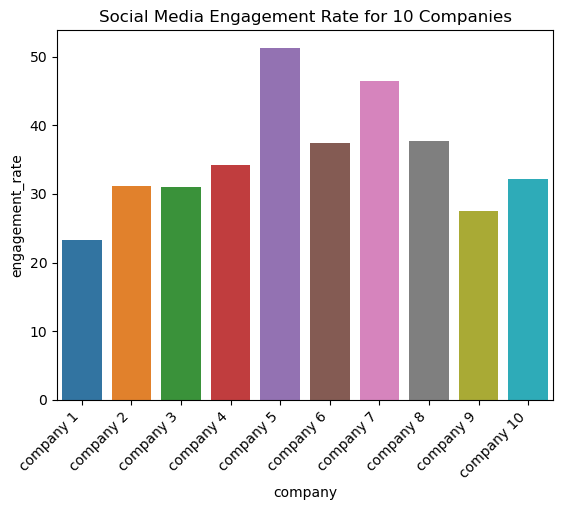

In [9]:
# visualize engagement rate for the first 10 companies in the dataset

# create a bar plot using seaborn
sns.barplot(data.iloc[0:10], x="company", y="engagement_rate")

# rotate the x ticks by 45 degrees and horizontally align to the right
plt.xticks(rotation=45, ha="right")

# add a title
plt.title("Social Media Engagement Rate for 10 Companies")

# display the plot
plt.show()

In [10]:
# calculate engagement rate and add this as a new column to data_over_time

data_over_time['engagement_rate'] = ((data_over_time['likes'] + data_over_time['shares'] + data_over_time['comments']) / data_over_time['followers']) * 100

In [11]:
# extract month from date and add this as a new column to data_over_time

data_over_time['month'] = data_over_time['date'].dt.month

In [12]:
# check out the updates

data_over_time

,date,posts,followers,likes,shares,comments,engagement_rate,month
0,2023-01-24 22:08:38.669438,16,6931,247,147,65,6.622421,1
1,2023-01-25 22:08:38.669438,29,6012,772,86,34,14.836993,1
2,2023-01-26 22:08:38.669438,24,6664,536,124,44,10.564226,1
3,2023-01-27 22:08:38.669438,20,6081,225,119,97,7.252097,1
4,2023-01-28 22:08:38.669438,17,9729,456,195,90,7.616405,1
...,...,...,...,...,...,...,...,...
360,2024-01-19 22:08:38.669438,28,6753,693,73,23,11.683696,1
361,2024-01-20 22:08:38.669438,26,7296,203,109,94,5.564693,1
362,2024-01-21 22:08:38.669438,28,7261,641,171,26,11.541110,1
363,2024-01-22 22:08:38.669438,14,7286,228,180,93,6.876201,1


In [13]:
# calculate average posts per month

avg_posts_per_month = data_over_time.groupby('month')['posts'].mean().reset_index()
avg_posts_per_month

,month,posts
0,1,20.548387
1,2,19.107143
2,3,19.225806
3,4,18.366667
4,5,18.193548
5,6,18.533333
6,7,18.709677
7,8,20.064516
8,9,19.666667
9,10,18.000000


In [14]:
# calculate average engagement rate per month

avg_engagement_rate_per_month = data_over_time.groupby('month')['engagement_rate'].mean().reset_index()
avg_engagement_rate_per_month

,month,engagement_rate
0,1,8.955270
1,2,8.218693
2,3,9.549912
3,4,9.449452
4,5,9.312644
5,6,9.287964
6,7,9.298311
7,8,8.589514
8,9,9.257955
9,10,8.499827


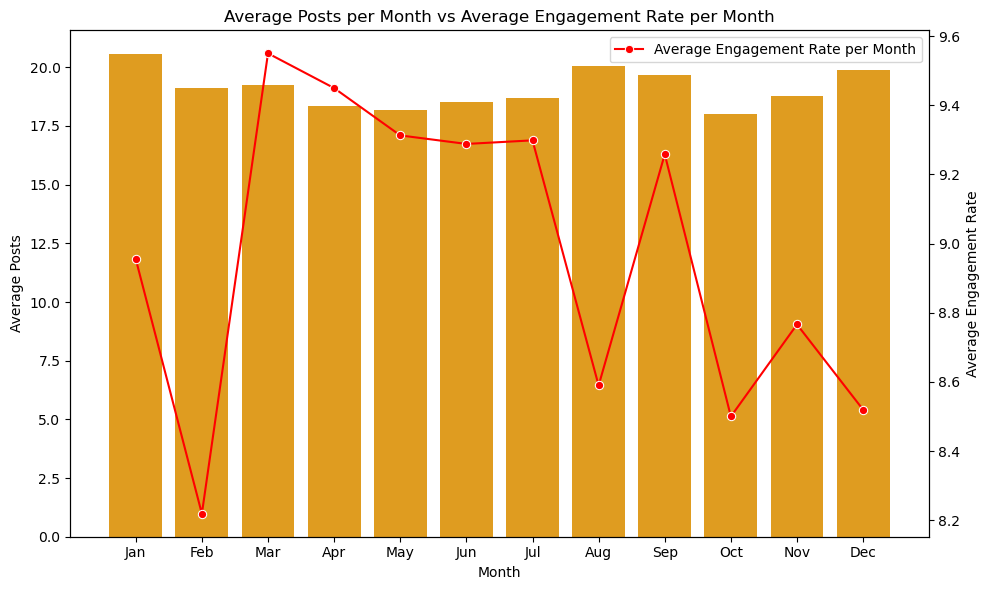

In [15]:
# visualize average posts per month and average engagement rate per month overlaid

# create subplots
fig, primary_axs = plt.subplots(1, 1, figsize=(10,6))

# create secondary axis 
secondary_axis = primary_axs.twinx()

# create bar plot for average posts per month
sns.barplot(data=avg_posts_per_month, x='month', y='posts', color='orange', label='Average Posts per Month', ax=primary_axs)

# create line plot for average engagement rate per month, shifted by 1 month to visually align with bar plot
avg_engagement_rate_per_month['month'] -= 1
sns.lineplot(data=avg_engagement_rate_per_month, x='month', y='engagement_rate', color='red', marker='o', label='Average Engagement Rate per Month')

# specify x-axis label 
primary_axs.set_xlabel("Month")

# specify primary y-axis label
primary_axs.set_ylabel("Average Posts")

# specify secondary y-axis label
secondary_axis.set_ylabel("Average Engagement Rate")

# add title 
plt.title('Average Posts per Month vs Average Engagement Rate per Month')

# add legend
plt.legend()

# specify x ticks
plt.xticks(ticks=range(0, 12), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

# adjust plot content to fit inside figure
plt.tight_layout()

# display plot
plt.show()